In [1]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def load_scores(file_path):
    steps = []
    scores = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            steps.append(data['step'])
            scores.append(data['episode/score'])
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

def plot_agent_scores(jsonl_paths, labels=None, window_size=50):
    from matplotlib.ticker import FuncFormatter
    color_list = ['tab:green', 'tab:pink', 'tab:grey', 'tab:blue']
    plt.figure(figsize=(4, 3))

    for i, path in enumerate(jsonl_paths):
        steps, scores = load_scores(path)

        # Sort by steps in case data is unordered
        sorted_indices = np.argsort(steps)
        steps, scores = steps[sorted_indices], scores[sorted_indices]

        # Apply smoothing
        smoothed_scores = smooth(scores, window_size)
        smoothed_steps = smooth(steps, window_size)

        # Compute std for shading
        #std = np.std(scores)
        std=0

        label = labels[i] if labels else f"Agent {i+1}"
        smoothed_steps = smoothed_steps/1e6
        plt.plot(smoothed_steps, smoothed_scores, label=label, c=color_list[i], linewidth=5)
        #plt.fill_between(smoothed_steps, smoothed_scores - std, smoothed_scores + std, alpha=0.2)

    plt.xlabel("Steps")
    #plt.ylabel("Score")
    plt.xticks([5, 10], ['5M', '10M'])  # Show only 5M and 10M
    plt.legend()
    plt.grid(True)
    plt.xlim(0,10)
    plt.tight_layout()
    plt.show()


In [2]:
plt.rcParams.update({'font.size': 16})

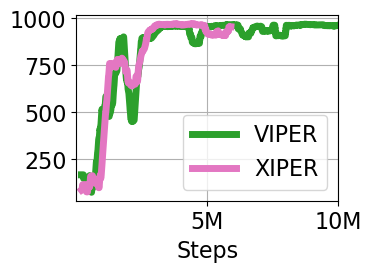

In [3]:
jsonl_paths = ["/home/zyang/XViper/logdir/dmc_cup_catch/2/scores.jsonl", "/home/zyang/XViper/logdir/dmc_cup_catch/20/scores.jsonl"]
#plot_agent_scores(jsonl_paths, labels=["VIPER", r'$\mathcal{X}$-VIPER'])
plot_agent_scores(jsonl_paths, labels=["VIPER", 'XIPER'])

In [38]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator
from matplotlib.ticker import MaxNLocator

from matplotlib.ticker import FuncFormatter

def load_scores(file_path):
    steps, scores = [], []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    if 'step' in data and 'episode/score' in data:
                        steps.append(data['step'])
                        scores.append(data['episode/score'])
                except json.JSONDecodeError as e:
                    print(f"[Warning] JSON decode error in {file_path}: {e}")
    except Exception as e:
        print(f"[Warning] Failed to open {file_path}: {e}")
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

def find_jsonl_files_recursively(folder_path):
    jsonl_files = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.jsonl'):
                jsonl_files.append(os.path.join(root, file))
    return jsonl_files

def aggregate_runs_in_folder(folder_path, window_size=50, use_ste=True):
    run_files = find_jsonl_files_recursively(folder_path)
    all_runs = []

    for path in run_files:
        steps, scores = load_scores(path)
        if len(steps) == 0 or len(scores) == 0:
            print(f"[Info] Skipping empty or bad file: {path}")
            continue

        sorted_indices = np.argsort(steps)
        steps, scores = steps[sorted_indices], scores[sorted_indices]
        all_runs.append((steps, scores))

    if len(all_runs) == 0:
        raise ValueError(f"No valid runs found in folder: {folder_path}")

    # Determine shared interpolation range
    min_end = min([steps[-1] for steps, _ in all_runs])
    max_start = max([steps[0] for steps, _ in all_runs])
    if min_end <= max_start:
        raise ValueError(f"Insufficient overlapping range in folder: {folder_path}")

    common_steps = np.linspace(max_start, min_end, 500)

    interpolated_scores = []
    for steps, scores in all_runs:
        interp_scores = np.interp(common_steps, steps, scores)
        interpolated_scores.append(interp_scores)

    interpolated_scores = np.array(interpolated_scores)
    mean_scores = np.mean(interpolated_scores, axis=0)
    error = (np.std(interpolated_scores, axis=0) / np.sqrt(len(interpolated_scores))) if use_ste else np.std(interpolated_scores, axis=0)

    # Smooth
    smoothed_mean = smooth(mean_scores, window_size)
    smoothed_error = smooth(error, window_size)
    smoothed_steps = smooth(common_steps, window_size)

    return smoothed_steps, smoothed_mean, smoothed_error

def plot_agent_folders(folder_paths, labels=None, window_size=50, use_ste=True, color_list=['tab:green', 'tab:pink', 'tab:grey', 'tab:blue', 'tab:orange', 'tab:red']):

    plt.figure(figsize=(4, 3))

    for i, folder in enumerate(folder_paths):
        try:
            steps, mean_scores, error = aggregate_runs_in_folder(folder, window_size, use_ste)
        except ValueError as e:
            print(f"[Error] Skipping folder due to issue: {e}")
            continue

        label = labels[i] if labels else f"Agent {i+1}"
        color = color_list[i % len(color_list)]
        steps = steps / 1e6
        plt.plot(steps, mean_scores, label=label, c=color, linewidth=5)
        plt.fill_between(steps, mean_scores - error, mean_scores + error, color=color, alpha=0.3)

    # Format x-axis ticks like "0", "5M", "10M"
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}M' if x != 0 else '0'))

    plt.xticks([5, 10], ['5M', '10M'])  # Show only 5M and 10M
    
    #ax = plt.gca()
    #ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None, integer=True))
    
    plt.xlabel("Steps")
    #plt.ylabel("Score")
    #plt.legend()
    #plt.legend(bbox_to_anchor=(0.5, -0.5))
    
    
    legend_y = -0.3 if len(folder_paths) <= 2 else -0.5
    plt.legend(bbox_to_anchor=(0.5, legend_y), loc='upper center')

    #plt.ylim(0,)
    plt.grid(True)
    #plt.tight_layout()
    #plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.tight_layout()

    plt.show()


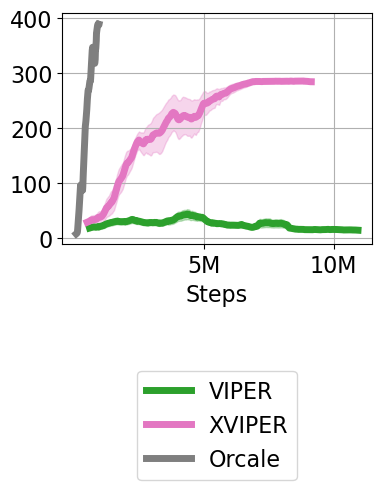

In [39]:
folders = ['logdir/dmc_cheetah_run/Viper/', 'logdir/dmc_cheetah_run/XViper/', 'logdir/dmc_cheetah_run/4/']
labels = ['VIPER', 'XVIPER', 'Orcale']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

In [40]:
plt.rcParams.update({'font.size': 16})

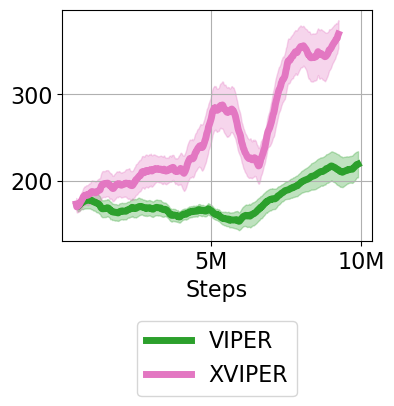

In [41]:
folders = ['logdir/dmc_cartpole_balance/Viper/', 'logdir/dmc_cartpole_balance/XViper/']
labels = ['VIPER', 'XVIPER', 'Orcale']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

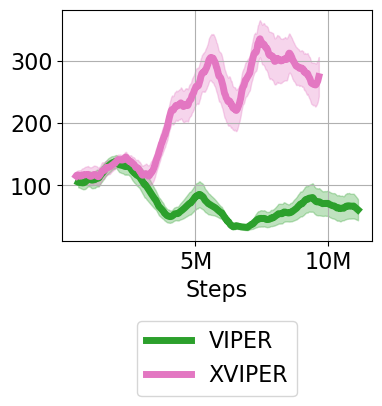

In [42]:
folders = ['logdir/dmc_cartpole_swingup/Viper/', 'logdir/dmc_cartpole_swingup/XViper/']
labels = ['VIPER', 'XVIPER', 'Orcale']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

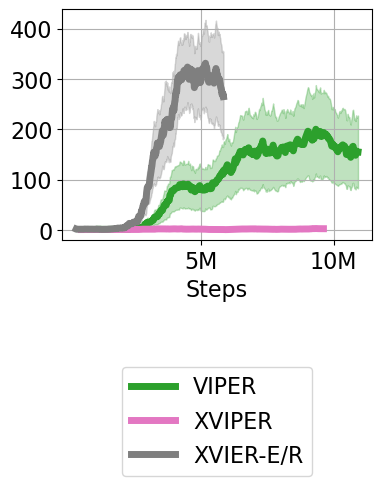

In [48]:
folders = ['logdir/dmc_pointmass_easy/Viper/', 'logdir/dmc_pointmass_easy/XViper/', 'logdir/dmc_pointmass_easy/XViper_separateOT_expert_data_best_ot/']
labels = ['VIPER', 'XVIPER', 'XVIER-E/R']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

### XIPER with different OT (FID) and training data

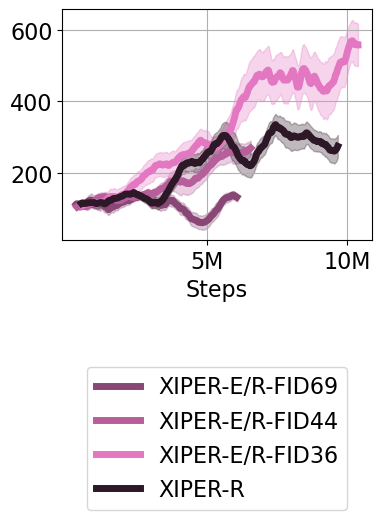

In [44]:
folders = ['logdir/dmc_cartpole_swingup/XViper_separateOT_expert_data/', 'logdir/dmc_cartpole_swingup/XViper_separateOT_expert_data_2999ot/', 'logdir/dmc_cartpole_swingup/XViper_separateOT_expert_data_best_ot/', 'logdir/dmc_cartpole_swingup/XViper/']
labels = ['XIPER-E/R-FID69', 'XIPER-E/R-FID44', 'XIPER-E/R-FID36', 'XIPER-R']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 0.6), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

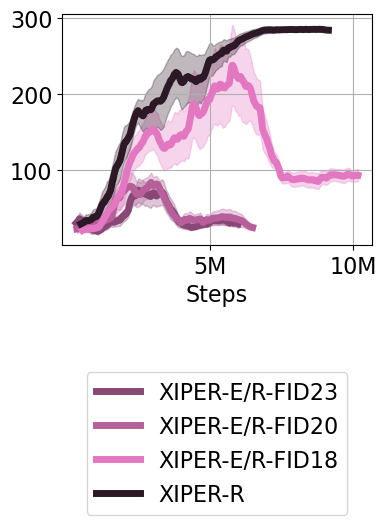

In [45]:
folders = ['logdir/dmc_cheetah_run/XViper_separateOT_expert_data/', 'logdir/dmc_cheetah_run/XViper_separateOT_expert_data_2999ot/', 'logdir/dmc_cheetah_run/XViper_separateOT_expert_data_best_ot/', 'logdir/dmc_cheetah_run/XViper/']
labels = ['XIPER-E/R-FID23', 'XIPER-E/R-FID20', 'XIPER-E/R-FID18', 'XIPER-R']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 0.6), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

In [14]:
from matplotlib.colors import to_rgb

In [15]:
def adjust_shade(rgb, factor):
    return tuple(min(1, c * factor) for c in rgb)

/scratch-local/71450/ipykernel_790155/2538345635.py:112: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # reserves space at bottom


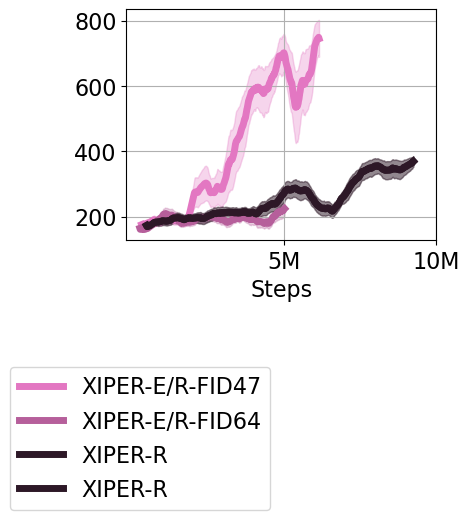

In [22]:
folders = ['logdir/dmc_cartpole_balance/XViper_separateOT_expert_data/', 'logdir/dmc_cartpole_balance/XViper_separateOT_expert_data_2999ot/', 'logdir/dmc_cartpole_balance/XViper/', 'logdir/dmc_cartpole_balance/XViper/']
labels = ['XIPER-E/R-FID47', 'XIPER-E/R-FID64', 'XIPER-R', 'XIPER-R']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

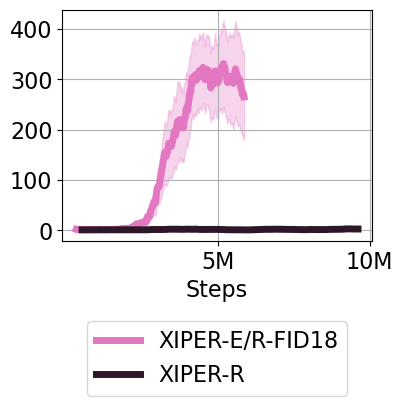

In [46]:
folders = ['logdir/dmc_pointmass_easy/XViper_separateOT_expert_data_best_ot/', 'logdir/dmc_pointmass_easy/XViper/']
labels = ['XIPER-E/R-FID18', 'XIPER-R']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

### VideoGPT reward visualization

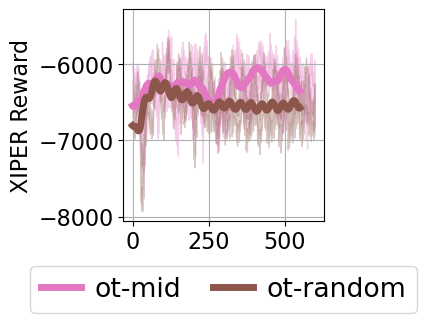

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# === Load the data ===
#rewards_expert = np.load('./good_bad_videos/dmc_cheetah_run/good_cheetah_rewards_ot.npy', allow_pickle=True)
#rewards_random = np.load('./good_bad_videos/dmc_cheetah_run/bad_cheetah_rewards_ot.npy', allow_pickle=True)

#rewards_expert = np.load('./good_bad_videos/dmc_cartpole_balance/mid_cartpole_balance_rewards_ot.npy', allow_pickle=True)
#rewards_random = np.load('./good_bad_videos/dmc_cartpole_balance/bad_cartpole_balance_rewards_ot.npy', allow_pickle=True)

rewards_expert = np.load('./good_bad_videos/atari_pong/mid_pong_rewards_ot.npy', allow_pickle=True)
rewards_random = np.load('./good_bad_videos/atari_pong/bad_pong_rewards_ot.npy', allow_pickle=True)

# === Trim all sequences to the same min length ===
min_len = min(
    min(len(r) for r in rewards_expert),
    min(len(r) for r in rewards_random)
)
rewards_expert_trimmed = np.array([r[:min_len] for r in rewards_expert])
rewards_random_trimmed = np.array([r[:min_len] for r in rewards_random])

# === Compute mean and SE ===
mean_expert = np.mean(rewards_expert_trimmed, axis=0)
ste_expert = np.std(rewards_expert_trimmed, axis=0) / np.sqrt(len(rewards_expert_trimmed))

mean_random = np.mean(rewards_random_trimmed, axis=0)
ste_random = np.std(rewards_random_trimmed, axis=0) / np.sqrt(len(rewards_random_trimmed))

# === Plot ===
plt.figure(figsize=(4, 4))

plt.plot(smooth(mean_expert, 50), label='ot-mid', color='tab:pink', linewidth=5)
plt.fill_between(range(min_len), mean_expert - ste_expert, mean_expert + ste_expert,
                 color='tab:pink', alpha=0.3)

plt.plot(smooth(mean_random, 50), label='ot-random', color='tab:brown', linewidth=5)
plt.fill_between(range(min_len), mean_random - ste_random, mean_random + ste_random,
                 color='tab:brown', alpha=0.3)

# === Customize legend ===
options = dict(
    fontsize='large', numpoints=1, labelspacing=0, columnspacing=1.2,
    handlelength=1.5, handletextpad=0.5, ncol=2, loc='lower center', frameon=True, fancybox=True
)
plt.legend(bbox_to_anchor=(0.5, -0.5), **options)

# === Labels and layout ===
plt.ylabel('XIPER Reward')
plt.grid(True)
plt.tight_layout()
plt.show()